# So sánh kết quả batch random test: `smooth` (planner hiện tại) vs `smooth_v0`

So sánh hai bộ kết quả:
- `results_inflate_doan_trinh_smooth/batch_random_test_summary.json` — planner chính (`core/kinodynamic_astar.py`)
- `results_inflate_doan_trinh_smooth_v0/batch_random_test_summary.json` — planner v0 (`core/kinodynamic_astar_v0.py`)

Ghép theo `scenario_name` (khóa duy nhất, 200 scenario mỗi file). So sánh:
1. Tỷ lệ success tổng thể
2. Các case một bên success, bên kia failed (2 chiều)
3. Với case cả hai cùng success: so sánh `total_time`, `distance_m`, `waypoints`

In [1]:
import json

import matplotlib.pyplot as plt
import pandas as pd


# Fixed categorical order (dataviz palette): slot 1 = blue, slot 2 = orange
COLOR_SMOOTH = "#2a78d6"  # smooth (main planner)
COLOR_V0 = "#eb6834"  # smooth_v0 (v0 planner)

pd.set_option("display.max_rows", 200)
pd.set_option("display.width", 140)

FILE_SMOOTH = "results_inflate_doan_trinh_smooth/batch_random_test_summary.json"
FILE_V0 = "results_inflate_doan_trinh_smooth_v0/batch_random_test_summary.json"

with open(FILE_SMOOTH) as f:
    data_smooth = json.load(f)
with open(FILE_V0) as f:
    data_v0 = json.load(f)

df_smooth = pd.DataFrame(data_smooth)
df_v0 = pd.DataFrame(data_v0)

print(
    f"smooth   : {len(df_smooth)} scenarios, {df_smooth['scenario_name'].nunique()} unique names"
)
print(
    f"smooth_v0: {len(df_v0)} scenarios, {df_v0['scenario_name'].nunique()} unique names"
)

smooth   : 200 scenarios, 200 unique names
smooth_v0: 200 scenarios, 200 unique names


In [2]:
# Ghép hai bảng theo scenario_name (outer join để không mất case nào chỉ có ở 1 bên)
cols = [
    "scenario_name",
    "status",
    "total_time",
    "waypoints",
    "distance_m",
    "iterations",
    "obstacles",
]
merged = df_smooth[cols].merge(
    df_v0[cols],
    on="scenario_name",
    how="outer",
    suffixes=("_smooth", "_v0"),
    indicator=True,
)
print("merge indicator counts:")
print(merged["_merge"].value_counts())
merged = merged.drop(columns="_merge")
merged.head()

merge indicator counts:
_merge
both          200
left_only       0
right_only      0
Name: count, dtype: int64


,scenario_name,status_smooth,total_time_smooth,waypoints_smooth,distance_m_smooth,iterations_smooth,obstacles_smooth,status_v0,total_time_v0,waypoints_v0,distance_m_v0,iterations_v0,obstacles_v0
0,Random Scenario 1,SUCCESS,0.807783,10,273727.817189,538,"9 I, 15 D",SUCCESS,1.497990,9,275212.235041,127,"9 I, 15 D"
1,Random Scenario 10,FAILED,0.008573,0,0.000000,1,"19 I, 2 D",FAILED,0.008493,0,0.000000,1,"19 I, 2 D"
2,Random Scenario 100,SUCCESS,0.457936,3,240572.272051,57,"15 I, 6 D",SUCCESS,0.699664,3,240572.272051,18,"15 I, 6 D"
3,Random Scenario 101,FAILED,0.000000,0,0.000000,1,"3 I, 17 D",FAILED,0.002014,0,0.000000,1,"3 I, 17 D"
4,Random Scenario 102,SUCCESS,0.647108,6,214014.779248,384,"6 I, 10 D",SUCCESS,0.658319,6,214222.567079,63,"6 I, 10 D"


## 1. Tỷ lệ success tổng thể

In [3]:
def success_rate(df):
    n = len(df)
    n_ok = (df["status"] == "SUCCESS").sum()
    return n_ok, n, n_ok / n * 100


ok_smooth, n_smooth, rate_smooth = success_rate(df_smooth)
ok_v0, n_v0, rate_v0 = success_rate(df_v0)

summary_rate = pd.DataFrame(
    {
        "planner": ["smooth", "smooth_v0"],
        "success": [ok_smooth, ok_v0],
        "total": [n_smooth, n_v0],
        "success_rate_%": [rate_smooth, rate_v0],
    }
).set_index("planner")
summary_rate

,success,total,success_rate_%
planner,,,
smooth,198,200,99.0
smooth_v0,197,200,98.5


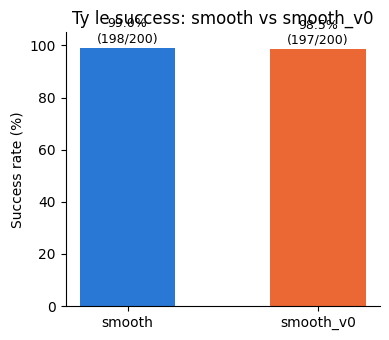

In [4]:
fig, ax = plt.subplots(figsize=(4, 3.5))
planners = ["smooth", "smooth_v0"]
rates = [rate_smooth, rate_v0]
colors = [COLOR_SMOOTH, COLOR_V0]
bars = ax.bar(planners, rates, color=colors, width=0.5)
for bar, rate, n_ok, n in zip(bars, rates, [ok_smooth, ok_v0], [n_smooth, n_v0]):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        rate + 1,
        f"{rate:.1f}%\n({n_ok}/{n})",
        ha="center",
        va="bottom",
        fontsize=9,
    )
ax.set_ylabel("Success rate (%)")
ax.set_ylim(0, 105)
ax.set_title("Ty le success: smooth vs smooth_v0")
for spine in ["top", "right"]:
    ax.spines[spine].set_visible(False)
plt.tight_layout()
plt.show()

## 2. Case khác biệt trạng thái (một bên success, bên kia failed)

In [5]:
diverge = merged[merged["status_smooth"] != merged["status_v0"]].copy()
diverge = diverge[["scenario_name", "status_smooth", "status_v0", "obstacles_smooth"]]
diverge = diverge.rename(columns={"obstacles_smooth": "obstacles"})

smooth_wins = diverge[
    (diverge["status_smooth"] == "SUCCESS") & (diverge["status_v0"] != "SUCCESS")
]
v0_wins = diverge[
    (diverge["status_v0"] == "SUCCESS") & (diverge["status_smooth"] != "SUCCESS")
]

print(f"Tong so case khac biet trang thai: {len(diverge)}")
print(f"  smooth SUCCESS, smooth_v0 FAILED: {len(smooth_wins)}")
print(f"  smooth_v0 SUCCESS, smooth FAILED: {len(v0_wins)}")
diverge

Tong so case khac biet trang thai: 1
  smooth SUCCESS, smooth_v0 FAILED: 1
  smooth_v0 SUCCESS, smooth FAILED: 0


,scenario_name,status_smooth,status_v0,obstacles
23,Random Scenario 12,SUCCESS,FAILED,"19 I, 20 D"


## 3. Case cả hai cùng SUCCESS: so sánh thời gian, quãng đường, waypoint

In [6]:
both_ok = merged[
    (merged["status_smooth"] == "SUCCESS") & (merged["status_v0"] == "SUCCESS")
].copy()
print(f"So case ca hai cung SUCCESS: {len(both_ok)}")

both_ok["time_diff"] = both_ok["total_time_smooth"] - both_ok["total_time_v0"]
both_ok["time_ratio"] = both_ok["total_time_smooth"] / both_ok["total_time_v0"]
both_ok["distance_diff_m"] = both_ok["distance_m_smooth"] - both_ok["distance_m_v0"]
both_ok["distance_diff_%"] = both_ok["distance_diff_m"] / both_ok["distance_m_v0"] * 100
both_ok["waypoints_diff"] = both_ok["waypoints_smooth"] - both_ok["waypoints_v0"]

metrics_summary = pd.DataFrame(
    {
        "mean": [
            both_ok["time_diff"].mean(),
            both_ok["distance_diff_m"].mean(),
            both_ok["distance_diff_%"].mean(),
            both_ok["waypoints_diff"].mean(),
        ],
        "median": [
            both_ok["time_diff"].median(),
            both_ok["distance_diff_m"].median(),
            both_ok["distance_diff_%"].median(),
            both_ok["waypoints_diff"].median(),
        ],
    },
    index=[
        "total_time diff (s, smooth-v0)",
        "distance diff (m, smooth-v0)",
        "distance diff (%, smooth-v0)",
        "waypoints diff (smooth-v0)",
    ],
)
metrics_summary

So case ca hai cung SUCCESS: 197


,mean,median
"total_time diff (s, smooth-v0)",-0.087252,-0.054774
"distance diff (m, smooth-v0)",-1092.836177,-313.153299
"distance diff (%, smooth-v0)",-0.409607,-0.122879
waypoints diff (smooth-v0),1.137056,0.000000


In [7]:
print("total_time (s): smooth vs smooth_v0")
print(
    both_ok[["total_time_smooth", "total_time_v0"]]
    .describe()
    .loc[["mean", "50%", "min", "max"]]
)
print()
print("distance_m: smooth vs smooth_v0")
print(
    both_ok[["distance_m_smooth", "distance_m_v0"]]
    .describe()
    .loc[["mean", "50%", "min", "max"]]
)
print()
print("waypoints: smooth vs smooth_v0")
print(
    both_ok[["waypoints_smooth", "waypoints_v0"]]
    .describe()
    .loc[["mean", "50%", "min", "max"]]
)

total_time (s): smooth vs smooth_v0
      total_time_smooth  total_time_v0
mean           1.055371       1.142624
50%            0.531960       0.656082
min            0.000000       0.016099
max            8.256967      13.210089

distance_m: smooth vs smooth_v0
      distance_m_smooth  distance_m_v0
mean      253313.763863  254406.600040
50%       252425.725167  254180.483126
min       203122.262419  203122.262419
max       334010.286567  337050.773051

waypoints: smooth vs smooth_v0
      waypoints_smooth  waypoints_v0
mean           6.15736      5.020305
50%            6.00000      5.000000
min            2.00000      2.000000
max           25.00000     18.000000


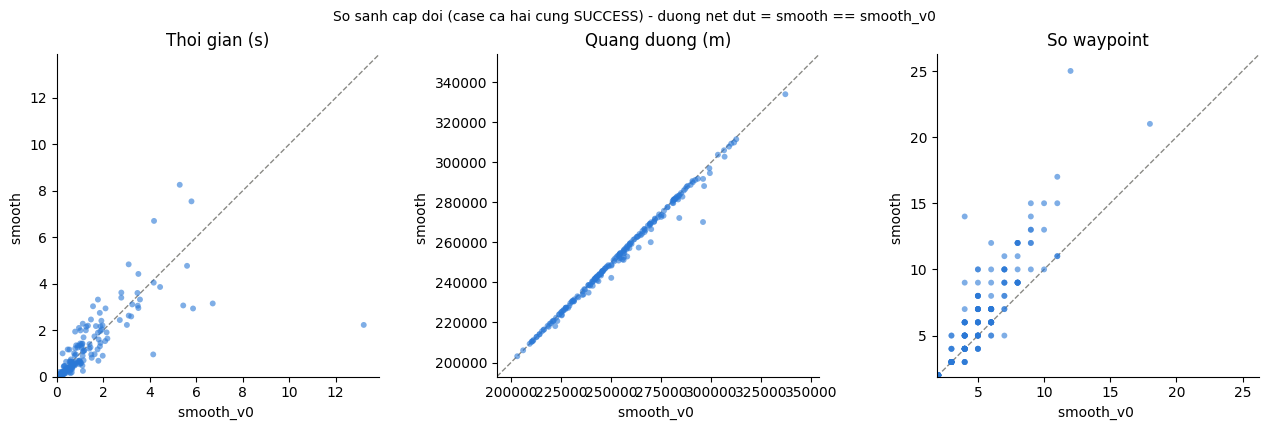

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(13, 4.2))


def paired_scatter(ax, x, y, label, unit=""):
    lim = [min(x.min(), y.min()) * 0.95, max(x.max(), y.max()) * 1.05]
    ax.plot(lim, lim, color="#8a8a86", linewidth=1, linestyle="--", zorder=1)
    ax.scatter(x, y, s=18, color=COLOR_SMOOTH, alpha=0.6, edgecolors="none", zorder=2)
    ax.set_xlim(lim)
    ax.set_ylim(lim)
    ax.set_xlabel(f"smooth_v0 {unit}")
    ax.set_ylabel(f"smooth {unit}")
    ax.set_title(label)
    ax.set_aspect("equal", adjustable="box")
    for spine in ["top", "right"]:
        ax.spines[spine].set_visible(False)


paired_scatter(
    axes[0], both_ok["total_time_v0"], both_ok["total_time_smooth"], "Thoi gian (s)"
)
paired_scatter(
    axes[1], both_ok["distance_m_v0"], both_ok["distance_m_smooth"], "Quang duong (m)"
)
paired_scatter(
    axes[2], both_ok["waypoints_v0"], both_ok["waypoints_smooth"], "So waypoint"
)

fig.suptitle(
    "So sanh cap doi (case ca hai cung SUCCESS) - duong net dut = smooth == smooth_v0",
    fontsize=10,
)
plt.tight_layout()
plt.show()

Điểm nằm **dưới** đường nét đứt (`y = x`) nghĩa là `smooth` thấp hơn `smooth_v0` ở trục đó (thời gian nhanh hơn / quãng đường ngắn hơn / ít waypoint hơn); điểm nằm **trên** nghĩa là `smooth_v0` thấp hơn.

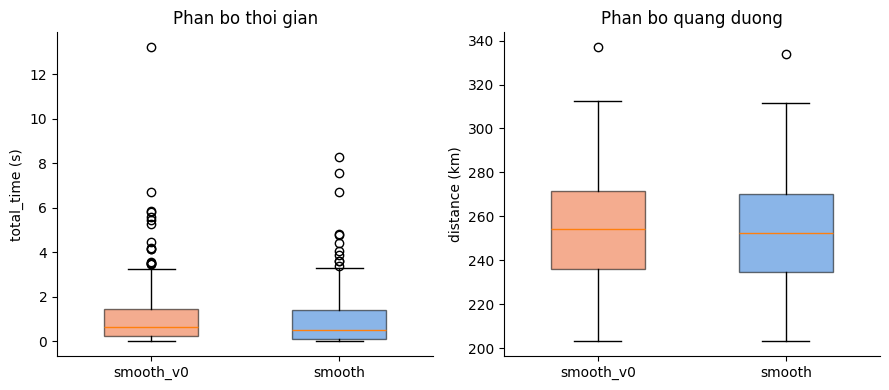

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(9, 4))

box_data_time = [both_ok["total_time_v0"], both_ok["total_time_smooth"]]
box_data_dist = [both_ok["distance_m_v0"] / 1000, both_ok["distance_m_smooth"] / 1000]
labels = ["smooth_v0", "smooth"]
colors = [COLOR_V0, COLOR_SMOOTH]

for ax, data, ylabel, title in [
    (axes[0], box_data_time, "total_time (s)", "Phan bo thoi gian"),
    (axes[1], box_data_dist, "distance (km)", "Phan bo quang duong"),
]:
    bp = ax.boxplot(data, labels=labels, patch_artist=True, widths=0.5)
    for patch, c in zip(bp["boxes"], colors):
        patch.set_facecolor(c)
        patch.set_alpha(0.55)
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    for spine in ["top", "right"]:
        ax.spines[spine].set_visible(False)

plt.tight_layout()
plt.show()

## 4. Bảng chi tiết case cùng SUCCESS (sắp theo chênh lệch quãng đường)

In [10]:
detail_cols = [
    "scenario_name",
    "total_time_smooth",
    "total_time_v0",
    "time_diff",
    "distance_m_smooth",
    "distance_m_v0",
    "distance_diff_m",
    "distance_diff_%",
    "waypoints_smooth",
    "waypoints_v0",
    "waypoints_diff",
]
both_ok[detail_cols].sort_values("distance_diff_%", ascending=False)

,scenario_name,total_time_smooth,total_time_v0,time_diff,distance_m_smooth,distance_m_v0,distance_diff_m,distance_diff_%,waypoints_smooth,waypoints_v0,waypoints_diff
78,Random Scenario 17,2.931458,5.861318,-2.929860,303793.400759,303364.667690,428.733069,0.141326,11,8,3
98,Random Scenario 188,0.291507,0.450505,-0.158998,215579.629153,215448.851338,130.777815,0.060700,4,5,-1
164,Random Scenario 67,0.953277,0.814910,0.138367,261291.331332,261154.349492,136.981839,0.052452,13,9,4
163,Random Scenario 66,0.026865,0.049256,-0.022391,268390.347666,268365.790853,24.556813,0.009151,3,4,-1
186,Random Scenario 87,0.047938,0.240035,-0.192097,265668.364664,265647.840161,20.524503,0.007726,3,4,-1
89,Random Scenario 18,0.661395,0.986364,-0.324969,290636.935889,290626.630386,10.305503,0.003546,4,5,-1
120,Random Scenario 27,0.387356,0.638681,-0.251325,273990.876817,273990.876817,0.000000,0.000000,3,3,0
116,Random Scenario 23,0.010262,0.054019,-0.043757,210236.954690,210236.954690,0.000000,0.000000,3,3,0
45,Random Scenario 14,0.013463,0.022344,-0.008880,230389.249622,230389.249622,0.000000,0.000000,2,2,0
144,Random Scenario 49,1.959648,1.872505,0.087142,254679.648569,254679.648569,0.000000,0.000000,6,6,0


## 5. Tổng kết

In [11]:
n_faster_smooth = (both_ok["time_diff"] < 0).sum()
n_shorter_smooth = (both_ok["distance_diff_m"] < 0).sum()
n_fewer_wp_smooth = (both_ok["waypoints_diff"] < 0).sum()

print(
    f"Success rate       : smooth {rate_smooth:.1f}% ({ok_smooth}/{n_smooth}) vs smooth_v0 {rate_v0:.1f}% ({ok_v0}/{n_v0})"
)
print(
    f"Case khac trang thai: {len(diverge)}  (smooth thang: {len(smooth_wins)}, smooth_v0 thang: {len(v0_wins)})"
)
print(f"Case ca hai SUCCESS : {len(both_ok)}")
print(
    f"  smooth nhanh hon    : {n_faster_smooth}/{len(both_ok)} case (trung binh {both_ok['time_diff'].mean():+.3f}s, trung vi {both_ok['time_diff'].median():+.3f}s)"
)
print(
    f"  smooth quang duong ngan hon: {n_shorter_smooth}/{len(both_ok)} case (trung binh {both_ok['distance_diff_%'].mean():+.2f}%, trung vi {both_ok['distance_diff_%'].median():+.2f}%)"
)
print(
    f"  smooth it waypoint hon     : {n_fewer_wp_smooth}/{len(both_ok)} case (trung binh {both_ok['waypoints_diff'].mean():+.2f})"
)

Success rate       : smooth 99.0% (198/200) vs smooth_v0 98.5% (197/200)
Case khac trang thai: 1  (smooth thang: 1, smooth_v0 thang: 0)
Case ca hai SUCCESS : 197
  smooth nhanh hon    : 140/197 case (trung binh -0.087s, trung vi -0.055s)
  smooth quang duong ngan hon: 140/197 case (trung binh -0.41%, trung vi -0.12%)
  smooth it waypoint hon     : 11/197 case (trung binh +1.14)
